In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from google.colab import files
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

In [2]:
#upload and load data files
uploaded = files.upload()

life = pd.read_csv("life_expectancy.csv", skiprows=4)
gdp = pd.read_csv("gdp_per_capita.csv", skiprows=4)
edu = pd.read_csv("school_enrollment.csv", skiprows=4)
ppp = pd.read_csv("purchase_power_parity_pp.csv", skiprows=4)
infl = pd.read_csv("infl_consumer_prices.csv", skiprows=4)
unemp = pd.read_csv("unemployment.csv", skiprows=4)
health = pd.read_csv("current_health_exp.csv", skiprows=4)

#selecting required date range (2000–2022)
cols = ['Country Name', 'Country Code'] + [str(y) for y in range(2000, 2023)]
datasets = [life, gdp, edu, ppp, infl, unemp, health]
datasets = [d[cols] for d in datasets]
life, gdp, edu, ppp, infl, unemp, health = datasets

Saving purchase_power_parity_pp.csv to purchase_power_parity_pp.csv
Saving current_health_exp.csv to current_health_exp.csv
Saving unemployment.csv to unemployment.csv
Saving infl_consumer_prices.csv to infl_consumer_prices.csv
Saving life_expectancy.csv to life_expectancy.csv
Saving gdp_per_capita.csv to gdp_per_capita.csv
Saving school_enrollment.csv to school_enrollment.csv


In [3]:
def melt_data(df, var_name):
    return df.melt(id_vars=['Country Name', 'Country Code'], var_name='Year', value_name=var_name)

life_long = melt_data(life, 'Life_Expectancy')
gdp_long = melt_data(gdp, 'GDP_per_Capita')
edu_long = melt_data(edu, 'School_Enrollment')
ppp_long = melt_data(ppp, 'Purchase_power_parity')
infl_long = melt_data(infl, 'Inflation')
unemp_long = melt_data(unemp, 'Unemployment')
health_long = melt_data(health, 'Health_Expenditure')

#merge all data frames
df = life_long.merge(gdp_long, on=['Country Name','Country Code','Year'])
df = df.merge(edu_long, on=['Country Name','Country Code','Year'], how='left')
df = df.merge(ppp_long, on=['Country Name','Country Code','Year'], how='left')
df = df.merge(infl_long, on=['Country Name','Country Code','Year'], how='left')
df = df.merge(unemp_long, on=['Country Name','Country Code','Year'], how='left')
df = df.merge(health_long, on=['Country Name','Country Code','Year'], how='left')

In [4]:
ppp = pd.read_csv("purchase_power_parity_pp.csv", skiprows=4)

In [5]:
print("PPP indicator name:", ppp.loc[0, "Indicator Name"])
print("PPP indicator code:", ppp.loc[0, "Indicator Code"])

PPP indicator name: GDP per capita, PPP (current international $)
PPP indicator code: NY.GDP.PCAP.PP.CD


In [6]:
df[["Purchase_power_parity", "GDP_per_Capita", "Life_Expectancy"]].describe()

,Purchase_power_parity,GDP_per_Capita,Life_Expectancy
count,5657.000000,5934.000000,6095.000000
mean,18160.917457,14488.762336,70.380533
std,20688.798197,22869.305447,8.623757
min,403.983197,109.593814,14.665000
25%,3931.344106,1510.155933,64.994500
50%,10508.856989,4908.501290,71.856326
75%,25677.419080,18218.267506,76.786500
max,180939.439450,226052.001905,86.151000


In [7]:
print("Initial shape:", df.shape)
display(df.head(5))

# Missing % by column
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print("\nMissing values (%):")
display(missing.to_frame("missing_%"))

# --- Type fixes ---
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)

# --- Drop rows missing target ---
TARGET = "Life_Expectancy"
before = df.shape[0]
df = df.dropna(subset=[TARGET]).copy()
print(f"\nDropped {before - df.shape[0]} rows with missing {TARGET}")

# --- Remove duplicates ---
before = df.shape[0]
df = df.drop_duplicates().copy()
print(f"Dropped {before - df.shape[0]} duplicate rows")

# --- Keep only valid (positive) values where required ---
# Add any variables here that should never be <= 0 in your dataset
positive_cols = ["Life_Expectancy", "GDP_per_Capita"]
for c in positive_cols:
    if c in df.columns:
        before = df.shape[0]
        df = df[df[c] > 0].copy()
        print(f"Removed {before - df.shape[0]} rows where {c} <= 0")

print("\nAfter basic cleaning shape:", df.shape)
print("Year range:", df["Year"].min(), "to", df["Year"].max())
display(df.describe(include="all").T.head(15))

Initial shape: (6118, 10)


,Country Name,Country Code,Year,Life_Expectancy,GDP_per_Capita,School_Enrollment,Purchase_power_parity,Inflation,Unemployment,Health_Expenditure
0,Aruba,ABW,2000,72.939000,20681.023027,NaN,30245.706974,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,2000,52.557342,707.120378,27.737129,2167.022577,NaN,7.788317,42.686416
2,Afghanistan,AFG,2000,55.005000,174.930991,NaN,813.550256,NaN,7.935000,NaN
3,Africa Western and Central,AFW,2000,50.297983,516.932316,22.339140,2457.445111,NaN,4.551119,18.199851
4,Angola,AGO,2000,46.501000,563.733796,13.369070,3689.537808,NaN,16.682000,13.159986



Missing values (%):


,missing_%
Inflation,31.775090
School_Enrollment,27.966656
Unemployment,11.670481
Health_Expenditure,11.082053
Purchase_power_parity,7.535142
GDP_per_Capita,3.007519
Life_Expectancy,0.375940



Dropped 23 rows with missing Life_Expectancy
Dropped 0 duplicate rows
Removed 0 rows where Life_Expectancy <= 0
Removed 161 rows where GDP_per_Capita <= 0

After basic cleaning shape: (5934, 10)
Year range: 2000 to 2022


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country Name,5934,262,Uruguay,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country Code,5934,262,URY,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5934.0,NaN,NaN,NaN,2011.018874,6.61085,2000.0,2005.0,2011.0,2017.0,2022.0
Life_Expectancy,5934.0,NaN,NaN,NaN,70.321146,8.617555,14.665,64.8875,71.763427,76.76339,86.151
GDP_per_Capita,5934.0,NaN,NaN,NaN,14488.762336,22869.305447,109.593814,1510.155933,4908.50129,18218.267506,226052.001905
School_Enrollment,4355.0,NaN,NaN,NaN,79.304221,28.201562,5.94096,60.052629,86.18866,99.473638,164.079819
Purchase_power_parity,5657.0,NaN,NaN,NaN,18160.917457,20688.798197,403.983197,3931.344106,10508.856989,25677.41908,180939.43945
Inflation,4163.0,NaN,NaN,NaN,5.435909,13.810765,-16.859691,1.698748,3.331395,6.143567,557.201817
Unemployment,5336.0,NaN,NaN,NaN,7.830569,5.509081,0.1,4.155092,6.3125,9.92795,37.32
Health_Expenditure,5414.0,NaN,NaN,NaN,924.571478,1664.462318,4.175786,63.770715,248.125244,798.176646,12434.433594


In [8]:
#We start making the EDA plots below one by one

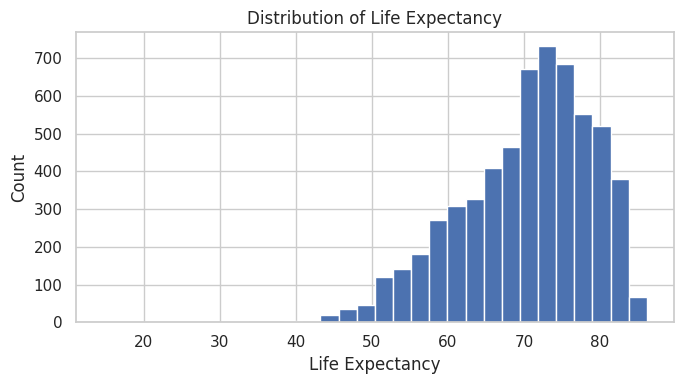

In [9]:
# ---------- 1) Target distribution ----------
plt.figure(figsize=(7,4))
plt.hist(df["Life_Expectancy"].dropna(), bins=30)
plt.xlabel("Life Expectancy")
plt.ylabel("Count")
plt.title("Distribution of Life Expectancy")
plt.tight_layout()
plt.show()

# ---------- 3) Create log features for money-like columns (for plotting only) ----------
for col in ["GDP_per_Capita", "Purchase_power_parity", "Health_Expenditure"]:
    if col in df.columns:
        dpos = df[df[col] > 0].copy()
        df["log_" + col] = np.where(df[col] > 0, np.log10(df[col]), np.nan)


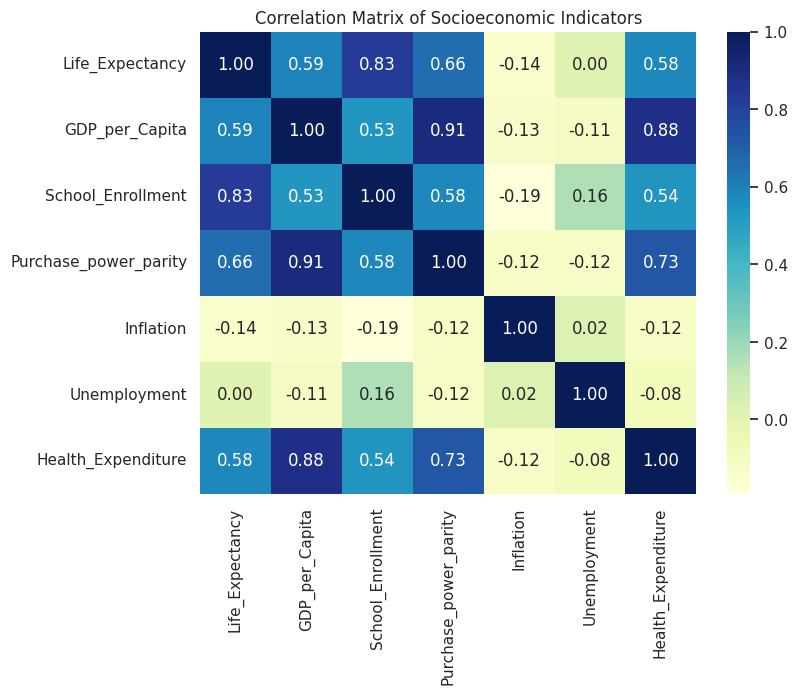

In [10]:
# ---------- 2) Correlation heatmap (numeric only) ----------
plt.figure(figsize=(8,6))
sns.heatmap(df[['Life_Expectancy','GDP_per_Capita','School_Enrollment','Purchase_power_parity',
                'Inflation','Unemployment','Health_Expenditure']].corr(),
            annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Correlation Matrix of Socioeconomic Indicators")
plt.show()

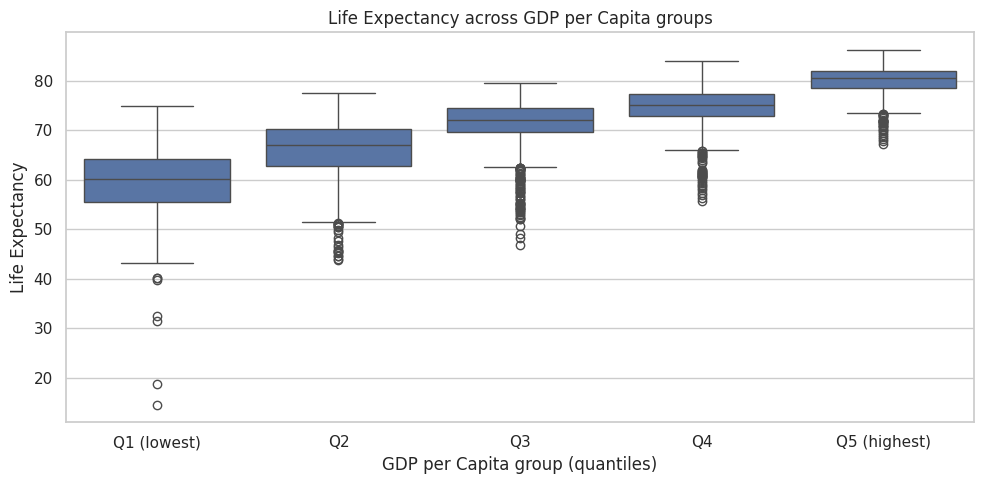

In [11]:
#---------------------------gdp vs percapita----------------#

# Keep only valid rows
d = df[df["GDP_per_Capita"].notna() & df["Life_Expectancy"].notna()].copy()
d = d[d["GDP_per_Capita"] > 0]  # GDP must be positive

# Create 5 GDP groups (Q1 = lowest GDP, Q5 = highest GDP)
d["GDP_group"] = pd.qcut(
    d["GDP_per_Capita"],
    q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]
)

plt.figure(figsize=(10,5))
sns.boxplot(data=d, x="GDP_group", y="Life_Expectancy", showfliers=True)
plt.xlabel("GDP per Capita group (quantiles)")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy across GDP per Capita groups")
plt.tight_layout()
plt.show()

In [12]:


d = df[df["GDP_per_Capita"].notna() & df["Life_Expectancy"].notna()].copy()
d = d[d["GDP_per_Capita"] > 0]

d["GDP_group"] = pd.qcut(d["GDP_per_Capita"], q=5,
                         labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])

def get_boxplot_outliers(group):
    y = group["Life_Expectancy"]
    q1 = y.quantile(0.25)
    q3 = y.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return group[(y < low) | (y > high)]

outliers = d.groupby("GDP_group", group_keys=False).apply(get_boxplot_outliers)

outliers = outliers.sort_values(["GDP_group", "Life_Expectancy"])
outliers[["Country Name", "Country Code", "Year", "GDP_group", "GDP_per_Capita", "Life_Expectancy"]].head(30)


/tmp/ipykernel_325/4207031583.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  outliers = d.groupby("GDP_group", group_keys=False).apply(get_boxplot_outliers)
/tmp/ipykernel_325/4207031583.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers = d.groupby("GDP_group", group_keys=False).apply(get_boxplot_outliers)


,Country Name,Country Code,Year,GDP_group,GDP_per_Capita,Life_Expectancy
2428,Central African Republic,CAF,2009,Q1 (lowest),456.471674,14.665
5886,Central African Republic,CAF,2022,Q1 (lowest),467.359825,18.818
5088,Central African Republic,CAF,2019,Q1 (lowest),449.228468,31.530
3139,"Somalia, Fed. Rep.",SOM,2011,Q1 (lowest),235.325946,32.453
4206,South Sudan,SSD,2015,Q1 (lowest),1080.147186,39.757
3758,Central African Republic,CAF,2014,Q1 (lowest),409.850486,40.265
5620,Central African Republic,CAF,2021,Q1 (lowest),492.263143,40.279
1288,Eswatini,SWZ,2004,Q2,2581.241728,43.906
1554,Eswatini,SWZ,2005,Q2,2945.363949,43.958
1820,Eswatini,SWZ,2006,Q2,3035.061561,44.563


In [13]:
outliers["GDP_group"].value_counts().sort_index()

,count
GDP_group,
Q1 (lowest),7
Q2,24
Q3,72
Q4,40
Q5 (highest),29


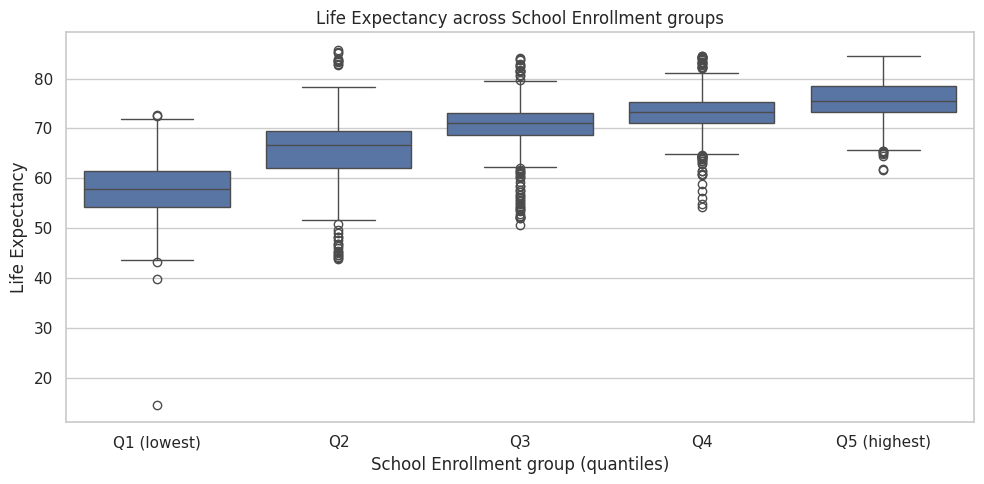

In [14]:
# Keep valid rows
d = df[df["School_Enrollment"].notna() & df["Life_Expectancy"].notna()].copy()

# Optional: if School_Enrollment is a percentage, it should usually be between 0 and 100
d = d[(d["School_Enrollment"] >= 0) & (d["School_Enrollment"] <= 100)]

# Create 5 enrollment groups
d["Enroll_group"] = pd.qcut(
    d["School_Enrollment"],
    q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"],
    duplicates="drop"
)

plt.figure(figsize=(10,5))
sns.boxplot(data=d, x="Enroll_group", y="Life_Expectancy", showfliers=True)
plt.xlabel("School Enrollment group (quantiles)")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy across School Enrollment groups")
plt.tight_layout()
plt.show()

In [15]:
d["School_Enrollment"].value_counts().head(10)

,count
School_Enrollment,
72.935181,2
74.952164,2
40.993000,2
44.032890,2
67.870354,2
44.704762,2
72.931412,2
63.298149,2
77.008148,2


In [16]:
d["School_Enrollment"].isna().mean()

np.float64(0.0)

In [17]:
d["School_Enrollment"].describe()

,School_Enrollment
count,3298.000000
mean,69.229937
std,24.171213
min,5.940960
25%,47.377218
50%,75.637106
75%,89.829774
max,99.995651


In [18]:
(df.isna().mean() * 100).sort_values(ascending=False)

,0
Inflation,29.844961
School_Enrollment,26.609370
Unemployment,10.077519
Health_Expenditure,8.763060
log_Health_Expenditure,8.763060
log_Purchase_power_parity,4.668015
Purchase_power_parity,4.668015
GDP_per_Capita,0.000000
Country Code,0.000000
Country Name,0.000000


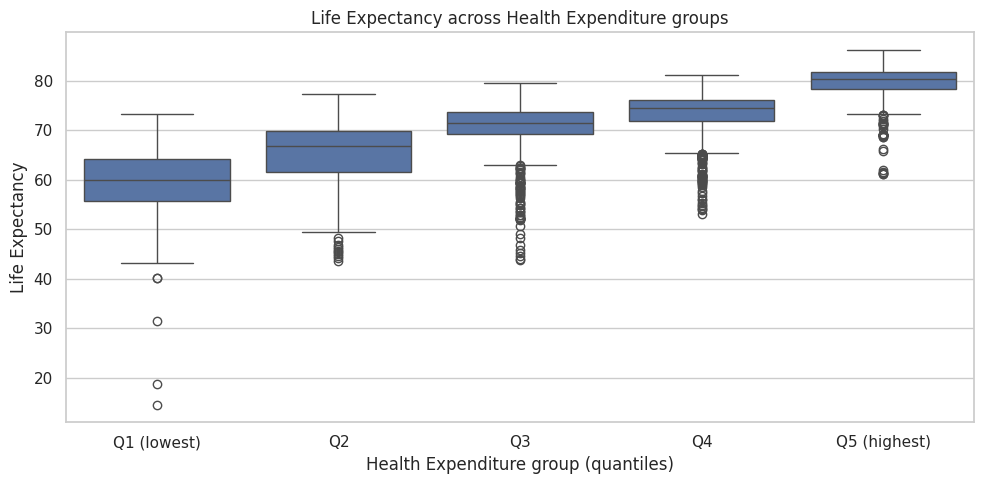

In [19]:
# Keep valid rows
d = df[df["Health_Expenditure"].notna() & df["Life_Expectancy"].notna()].copy()

# Health expenditure should be positive for log-like economics meaning (and for clean grouping)
d = d[d["Health_Expenditure"] > 0]

# Create 5 expenditure groups (Q1 lowest spending → Q5 highest spending)
d["Health_group"] = pd.qcut(
    d["Health_Expenditure"],
    q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"],
    duplicates="drop"
)

plt.figure(figsize=(10,5))
sns.boxplot(data=d, x="Health_group", y="Life_Expectancy", showfliers=True)
plt.xlabel("Health Expenditure group (quantiles)")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy across Health Expenditure groups")
plt.tight_layout()
plt.show()

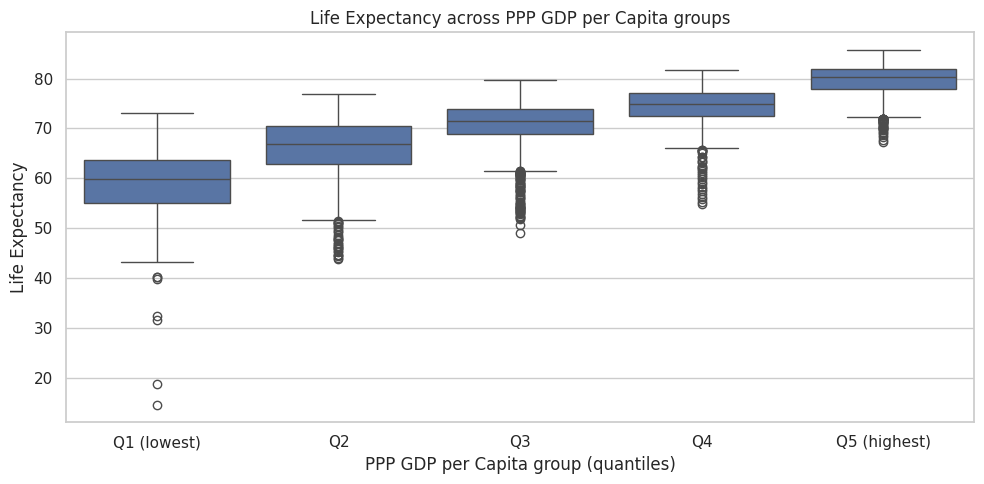

In [20]:
# Keep valid rows
d = df[df["Purchase_power_parity"].notna() & df["Life_Expectancy"].notna()].copy()
d = d[d["Purchase_power_parity"] > 0]

# Create 5 PPP groups (Q1 lowest → Q5 highest)
d["PPP_group"] = pd.qcut(
    d["Purchase_power_parity"],
    q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"],
    duplicates="drop"
)

plt.figure(figsize=(10,5))
sns.boxplot(data=d, x="PPP_group", y="Life_Expectancy", showfliers=True)
plt.xlabel("PPP GDP per Capita group (quantiles)")
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy across PPP GDP per Capita groups")
plt.tight_layout()
plt.show()

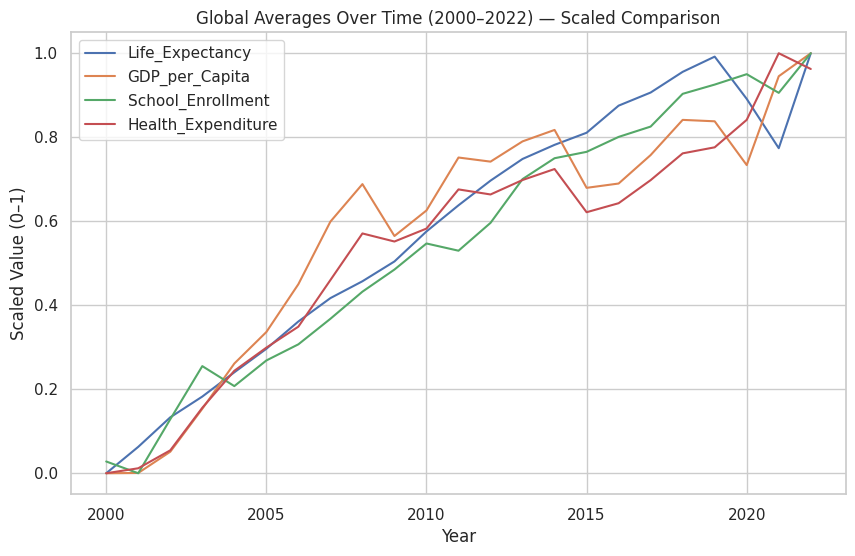

In [21]:
df_year = df.groupby('Year')[['Life_Expectancy', 'GDP_per_Capita',
                              'School_Enrollment', 'Health_Expenditure']].mean().reset_index()
scaler = MinMaxScaler()
df_scaled = df_year.copy()
cols_to_scale = ['Life_Expectancy', 'GDP_per_Capita', 'School_Enrollment', 'Health_Expenditure']
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

plt.figure(figsize=(10,6))
for col in cols_to_scale:
    sns.lineplot(data=df_scaled, x='Year', y=col, label=col)
plt.title("Global Averages Over Time (2000–2022) — Scaled Comparison")
plt.ylabel("Scaled Value (0–1)")
plt.legend()
plt.show()

In [39]:
ppp_col = "Purchase_power_parity"  # change if needed

d = df[[ "Country Name","Country Code","Year","Life_Expectancy","GDP_per_Capita", ppp_col ]].copy()

print("Total rows:", len(d))
print("Non-missing LE:", d["Life_Expectancy"].notna().sum())
print("Non-missing PPP:", d[ppp_col].notna().sum())
print("PPP > 0:", (d[ppp_col] > 0).sum())
print("Non-missing GDP:", d["GDP_per_Capita"].notna().sum())
print("GDP > 0:", (d["GDP_per_Capita"] > 0).sum())

d = d[d["Life_Expectancy"].notna() & d[ppp_col].notna() & (d[ppp_col] > 0)]
print("Rows after LE+PPP filters:", len(d))

Total rows: 5934
Non-missing LE: 5934
Non-missing PPP: 5657
PPP > 0: 5657
Non-missing GDP: 5934
GDP > 0: 5934
Rows after LE+PPP filters: 5657


In [40]:
ppp_col = "Purchase_power_parity"  # your PPP GDP per capita column

d = df[df[ppp_col].notna() & df["Life_Expectancy"].notna()].copy()
d = d[d[ppp_col] > 0]

# Lowest 20% PPP group
threshold = d[ppp_col].quantile(0.20)
low_ppp_group = d[d[ppp_col] <= threshold].copy()

# Top 10 life expectancy within that low-PPP group
top10 = low_ppp_group.sort_values("Life_Expectancy", ascending=False).head(10)

top10[["Country Name", "Country Code", "Year", ppp_col, "Life_Expectancy"]]

,Country Name,Country Code,Year,Purchase_power_parity,Life_Expectancy
789,Viet Nam,VNM,2002,3001.870388,73.138000
523,Viet Nam,VNM,2001,2808.831819,72.984000
276,Armenia,ARM,2001,2844.362664,72.975610
10,Armenia,ARM,2000,2530.743947,72.880488
257,Viet Nam,VNM,2000,2614.118404,72.746000
40,China,CHN,2000,2963.532386,72.288000
1260,West Bank and Gaza,PSE,2004,3013.739419,71.094000
994,West Bank and Gaza,PSE,2003,2469.379804,70.967000
728,West Bank and Gaza,PSE,2002,2178.863065,70.880000
260,Samoa,WSM,2000,3061.849867,70.791000


In [22]:
#feature engineering and model building

# --- Log features (only where value > 0) ---
df["log_GDP_per_Capita"] = np.where(df["GDP_per_Capita"] > 0, np.log10(df["GDP_per_Capita"]), np.nan)
df["log_PPP"] = np.where(df["Purchase_power_parity"] > 0, np.log10(df["Purchase_power_parity"]), np.nan)
df["log_Health_Expenditure"] = np.where(df["Health_Expenditure"] > 0, np.log10(df["Health_Expenditure"]), np.nan)

# --- Define features and target ---
TARGET = "Life_Expectancy"
FEATURES = [
    "log_GDP_per_Capita",
    "log_PPP",
    "log_Health_Expenditure",
    "School_Enrollment",
    "Inflation",
    "Unemployment"
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (5934, 6)
y shape: (5934,)


,log_GDP_per_Capita,log_PPP,log_Health_Expenditure,School_Enrollment,Inflation,Unemployment
0,4.315572,4.480664,NaN,NaN,NaN,NaN
1,2.849493,3.335863,1.630290,27.737129,NaN,7.788317
2,2.242867,2.910384,NaN,NaN,NaN,7.935000
3,2.713434,3.390484,1.260068,22.339140,NaN,4.551119
4,2.751074,3.566972,1.119255,13.369070,NaN,16.682000


In [23]:
#linear regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("lr", LinearRegression())
])

lr_model.fit(X_train, y_train)
pred = lr_model.predict(X_test)

print("Linear Regression performance:")
print("MAE :", mean_absolute_error(y_test, pred))
# Calculate RMSE by taking the square root of MSE
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))

Linear Regression performance:
MAE : 3.291565304135045
RMSE: 4.3803771536449645
R2  : 0.7332134044482357


In [24]:
#random forest regressor

rf_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

print("Random Forest performance:")
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2  :", r2_score(y_test, pred_rf))

Random Forest performance:
MAE : 1.6846058816707004
RMSE: 2.6385060613923597
R2  : 0.9032040498729533


In [25]:
#XGB baseline

xgb_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("xgb", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)

print("XGBoost performance:")
print("MAE :", mean_absolute_error(y_test, pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))
print("R2  :", r2_score(y_test, pred_xgb))

XGBoost performance:
MAE : 2.1146208529012505
RMSE: 2.9865469934209026
R2  : 0.8759834343941076


In [26]:
#tune RF Random search

rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "rf__n_estimators": [200, 400, 600, 800],
    "rf__max_depth": [None, 8, 12, 16, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", 0.5, 0.8]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=25,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_
pred_best_rf = best_rf.predict(X_test)

print("Tuned RF performance:")
print("MAE :", mean_absolute_error(y_test, pred_best_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_best_rf)))
print("R2  :", r2_score(y_test, pred_best_rf))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF params: {'rf__n_estimators': 400, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.8, 'rf__max_depth': None}
Tuned RF performance:
MAE : 1.6830754260119174
RMSE: 2.6019862307391604
R2  : 0.9058650312567194


In [27]:
from xgboost import XGBRegressor

xgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("xgb", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

xgb_param_dist = {
    "xgb__n_estimators": [300, 500, 800, 1200],
    "xgb__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "xgb__max_depth": [2, 3, 4, 5, 6],
    "xgb__subsample": [0.6, 0.8, 1.0],
    "xgb__colsample_bytree": [0.6, 0.8, 1.0],
    "xgb__reg_alpha": [0, 0.1, 1.0],
    "xgb__reg_lambda": [1.0, 5.0, 10.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=25,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGB params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_
pred_best_xgb = best_xgb.predict(X_test)

print("Tuned XGB performance:")
print("MAE :", mean_absolute_error(y_test, pred_best_xgb))
print("RMSE:",np.sqrt(mean_squared_error(y_test, pred_best_xgb)))
print("R2  :", r2_score(y_test, pred_best_xgb))

Best XGB params: {'xgb__subsample': 0.6, 'xgb__reg_lambda': 5.0, 'xgb__reg_alpha': 1.0, 'xgb__n_estimators': 500, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 1.0}
Tuned XGB performance:
MAE : 1.6829423093048834
RMSE: 2.5150443963661355
R2  : 0.9120507163982031


Permutation importance (Tuned XGBoost):


,feature,importance_mean,importance_std
0,log_GDP_per_Capita,3.172315,0.072342
1,log_PPP,2.803672,0.084433
2,log_Health_Expenditure,2.457229,0.085419
3,School_Enrollment,1.295428,0.070329
4,Unemployment,1.143901,0.040931
5,Inflation,0.294828,0.015819


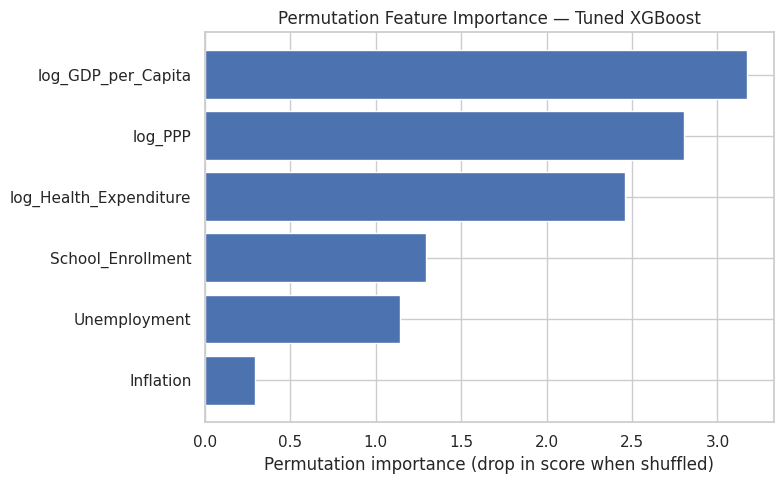

Permutation importance (Tuned Random Forest):


,feature,importance_mean,importance_std
0,log_GDP_per_Capita,3.549282,0.090746
1,log_PPP,2.004091,0.058390
2,log_Health_Expenditure,1.839605,0.064449
3,School_Enrollment,1.125889,0.053089
4,Unemployment,0.933642,0.030895
5,Inflation,0.234403,0.015672


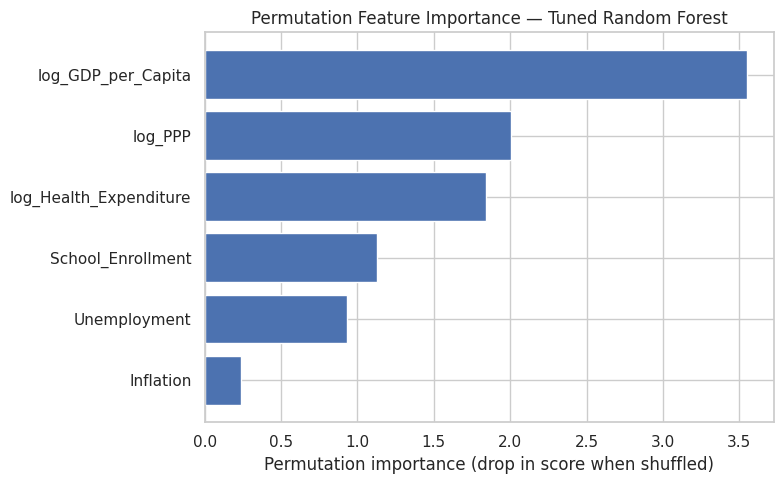

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def permutation_importance_df(model, X_test, y_test, feature_names, n_repeats=30, random_state=42):
    """
    Computes permutation importance on the test set.
    Returns a sorted DataFrame with mean and std importances.
    """
    r = permutation_importance(
        model, X_test, y_test,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring="neg_mean_absolute_error",  # consistent with your tuning
        n_jobs=-1
    )
    imp = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    return imp

def plot_importance(imp_df, title):
    plt.figure(figsize=(8, 5))
    plt.barh(imp_df["feature"][::-1], imp_df["importance_mean"][::-1])
    plt.xlabel("Permutation importance (drop in score when shuffled)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# --- XGB importance ---
imp_xgb = permutation_importance_df(best_xgb, X_test, y_test, FEATURES)
print("Permutation importance (Tuned XGBoost):")
display(imp_xgb)

plot_importance(imp_xgb, "Permutation Feature Importance — Tuned XGBoost")

# --- RF importance ---
imp_rf = permutation_importance_df(best_rf, X_test, y_test, FEATURES)
print("Permutation importance (Tuned Random Forest):")
display(imp_rf)

plot_importance(imp_rf, "Permutation Feature Importance — Tuned Random Forest")

,Model,R2,MAE,RMSE
0,Linear Regression,0.733213,3.291565,4.380377
1,Random Forest (tuned),0.905865,1.683075,2.601986
2,XGBoost (tuned),0.912051,1.682942,2.515044


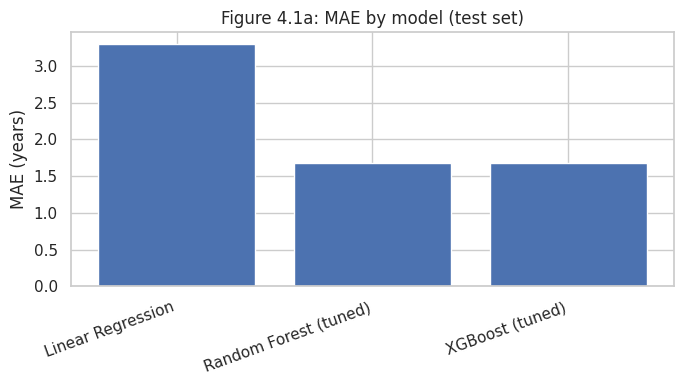

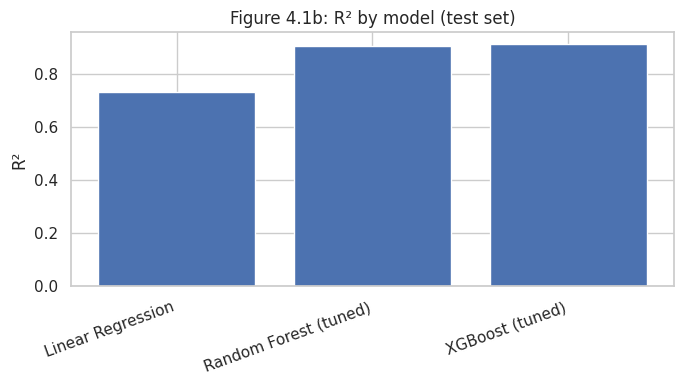

In [31]:
def eval_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    return {
        "Model": name,
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mse)
    }

results = []
results.append(eval_model("Linear Regression", lr_model, X_test, y_test))
results.append(eval_model("Random Forest (tuned)", best_rf, X_test, y_test))
results.append(eval_model("XGBoost (tuned)", best_xgb, X_test, y_test))

results_df = pd.DataFrame(results)
display(results_df)

# Bar chart for MAE
plt.figure(figsize=(7,4))
plt.bar(results_df["Model"], results_df["MAE"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("MAE (years)")
plt.title("Figure 4.1a: MAE by model (test set)")
plt.tight_layout()
plt.show()

# Bar chart for R2
plt.figure(figsize=(7,4))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("R²")
plt.title("Figure 4.1b: R² by model (test set)")
plt.tight_layout()
plt.show()

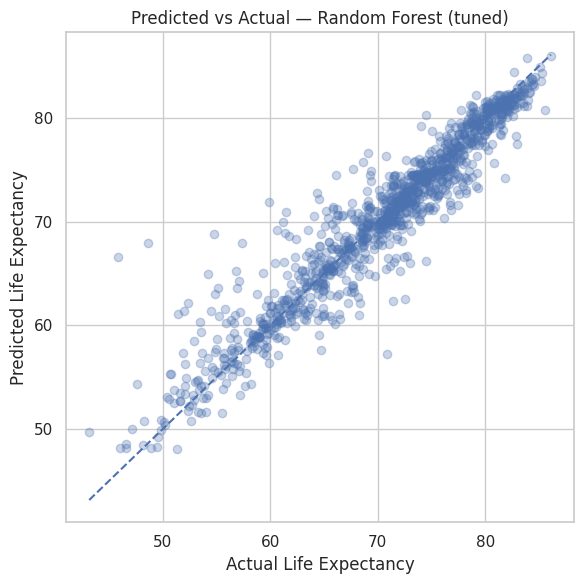

In [35]:
#predicted vs actual (RF tuned)
pred_rf = best_rf.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf, alpha=0.3)
minv = min(y_test.min(), pred_rf.min())
maxv = max(y_test.max(), pred_rf.max())
plt.plot([minv, maxv], [minv, maxv], linestyle="--")  # y=x line
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Predicted vs Actual — Random Forest (tuned)")
plt.tight_layout()
plt.show()

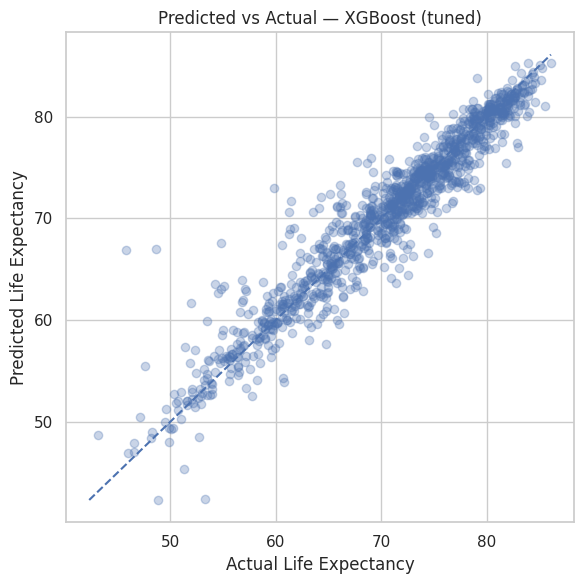

In [36]:
#predicted vs actual XGB(tuned)
pred_xgb = best_xgb.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_xgb, alpha=0.3)
minv = min(y_test.min(), pred_xgb.min())
maxv = max(y_test.max(), pred_xgb.max())
plt.plot([minv, maxv], [minv, maxv], linestyle="--")  # y=x line
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Predicted vs Actual — XGBoost (tuned)")
plt.tight_layout()
plt.show()

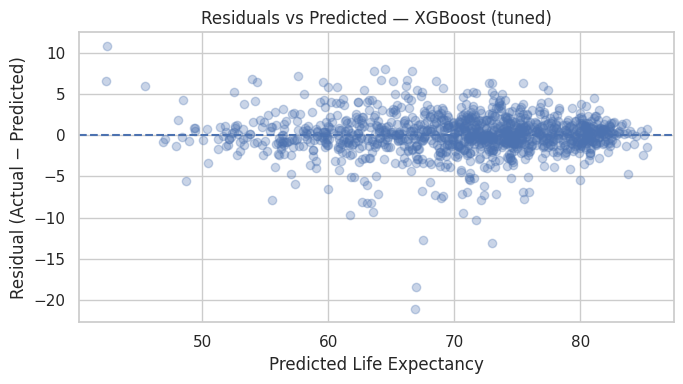

In [37]:
#residual (XGB)
resid_xgb = y_test - pred_xgb

plt.figure(figsize=(7,4))
plt.scatter(pred_xgb, resid_xgb, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residuals vs Predicted — XGBoost (tuned)")
plt.tight_layout()
plt.show()